Step 1: Import libraries and set configurations

In [1]:
# Step 1: Import libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

# Fix seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ TensorFlow version:", tf.__version__)


✅ TensorFlow version: 2.20.0


Step 2: Dataset Paths & Basic Info

Classes found: ['Benign', 'Malignant']
Train counts: {'Benign': 6289, 'Malignant': 5590}
Test counts: {'Benign': 1000, 'Malignant': 1000}


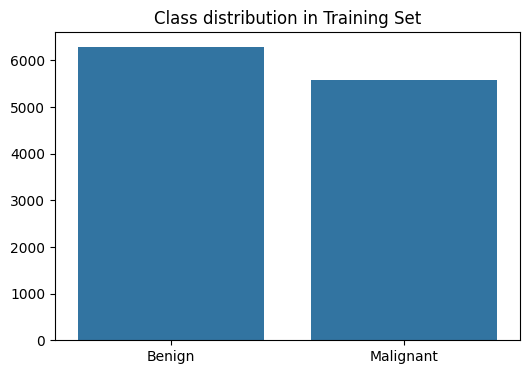

In [2]:
# Step 2: Dataset paths
BASE_DIR = r"C:\Users\SIDDU\Desktop\Melanoma_Cancer_Image_Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Check classes
classes = os.listdir(TRAIN_DIR)
print("Classes found:", classes)

# Count images per class
train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes}
test_counts = {cls: len(os.listdir(os.path.join(TEST_DIR, cls))) for cls in classes}

print("Train counts:", train_counts)
print("Test counts:", test_counts)

# Plot distribution
plt.figure(figsize=(6,4))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title("Class distribution in Training Set")
plt.show()



Step 3: Visualize Sample Images from Each Class

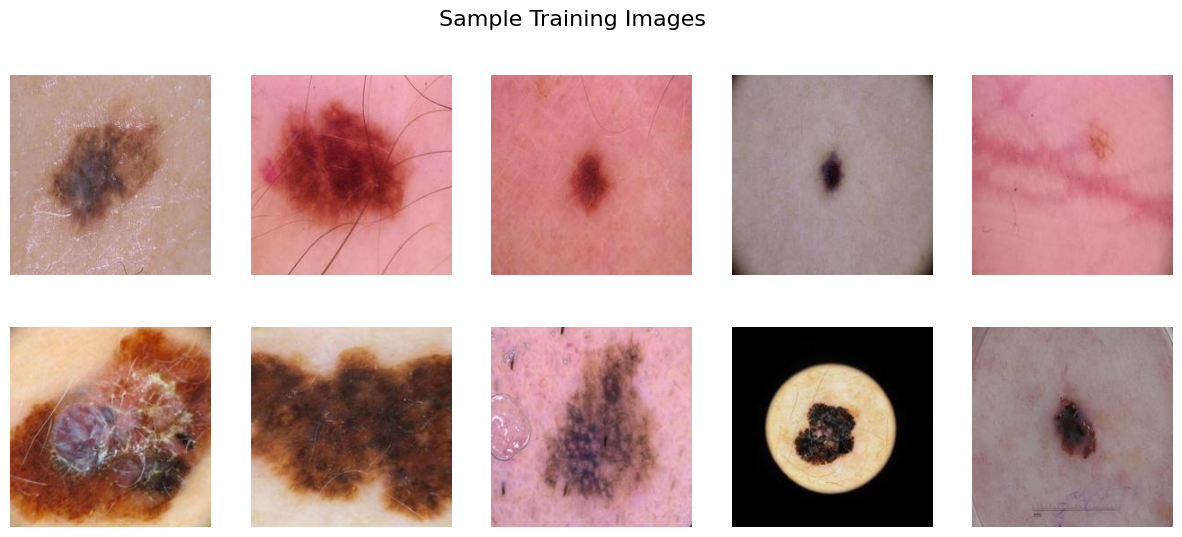

In [3]:
# Step 3: Show sample images from each class
import matplotlib.image as mpimg

def show_sample_images(dataset_dir, classes, samples_per_class=5):
    plt.figure(figsize=(15, 6))
    for idx, cls in enumerate(classes):
        class_dir = os.path.join(dataset_dir, cls)
        images = os.listdir(class_dir)
        random_imgs = random.sample(images, min(samples_per_class, len(images)))
        
        for i, img_name in enumerate(random_imgs):
            plt.subplot(len(classes), samples_per_class, idx*samples_per_class + i + 1)
            img_path = os.path.join(class_dir, img_name)
            img = mpimg.imread(img_path)
            plt.imshow(img)
            plt.axis("off")
            if i == 0:
                plt.ylabel(cls, fontsize=14)
    plt.suptitle("Sample Training Images", fontsize=16)
    plt.show()

show_sample_images(TRAIN_DIR, classes, samples_per_class=5)


Step 4: Image Preprocessing & Augmentation

In [4]:
# Step 4: Preprocessing & Augmentation

IMG_SIZE = (128, 128)   # resize target
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.15   # use part of training as validation
)

# Only rescaling for validation/test
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=1,
    class_mode='binary',
    shuffle=False
)


Found 10098 images belonging to 2 classes.
Found 1781 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


Step 5: Visualize Augmented Samples

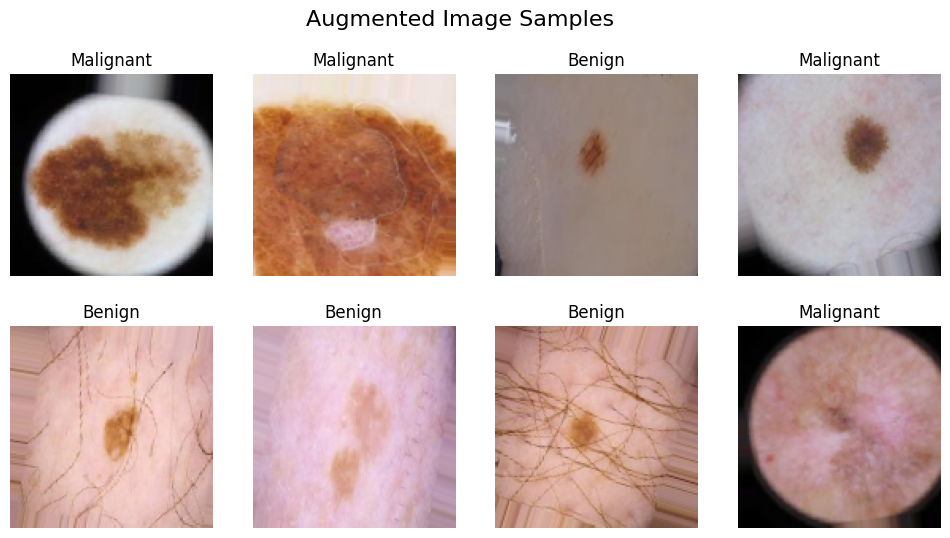

In [5]:
# Step 5: Visualize augmented images
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_batch[i])
    plt.axis("off")
    plt.title("Malignant" if y_batch[i]==1 else "Benign")
plt.suptitle("Augmented Image Samples", fontsize=16)
plt.show()


Step 6: Build a Custom CNN

In [6]:
# Step 6: Build Custom CNN Model

def build_custom_cnn(input_shape=(128,128,3)):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # binary output
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

custom_cnn = build_custom_cnn(input_shape=(128,128,3))
custom_cnn.summary()


C:\Users\SIDDU\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,194,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289,217 (16.36 MB)

 Trainable params: 4,288,513 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

Step 7: Train the Model

In [7]:
# Step 7: Train Custom CNN

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)

history = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # adjust as needed
    callbacks=[early_stop, reduce_lr]
)


C:\Users\SIDDU\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 502s 2s/step - accuracy: 0.8246 - loss: 0.4012 - val_accuracy: 0.5536 - val_loss: 1.2165 - learning_rate: 0.0010
Epoch 2/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.8465 - loss: 0.3426 - val_accuracy: 0.7395 - val_loss: 0.6256 - learning_rate: 0.0010
Epoch 3/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.8638 - loss: 0.3168 - val_accuracy: 0.6738 - val_loss: 0.7768 - learning_rate: 0.0010
Epoch 4/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 271s 858ms/step - accuracy: 0.8700 - loss: 0.3089 - val_accuracy: 0.5609 - val_loss: 1.1036 - learning_rate: 0.0010
Epoch 5/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.8782 - loss: 0.2916  
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
316/316 ━━━━━━━━━━━━━━━━━━━━ 273s 863ms/step - accuracy: 0.8723 - loss: 0.3021 - val_accuracy: 0.4739 - val_loss: 1.4264 - learning_rate: 0.0010
Epoch 6/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 271s 858ms/step - accuracy: 0.8820

In [8]:
# Save in HDF5 format
custom_cnn.save("custom_cnn_model.h5")
print("✅ Model saved as custom_cnn_model.h5")

✅ Model saved as custom_cnn_model.h5


Step 8: Plot Training Curves

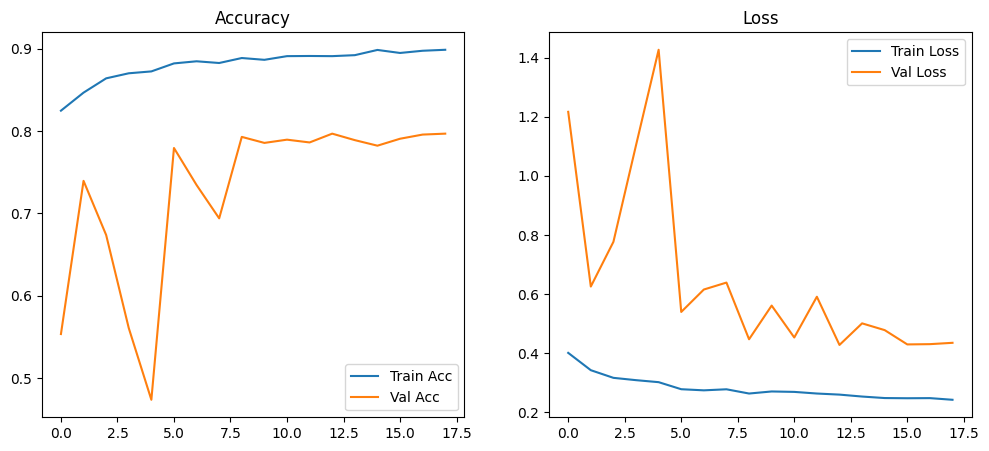

In [9]:
# Step 8: Training vs Validation Accuracy & Loss
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")

plt.show()


Step 9: Model Evaluation

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step
Classification Report:
              precision    recall  f1-score   support

      Benign       0.86      0.95      0.90      1000
   Malignant       0.95      0.84      0.89      1000

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



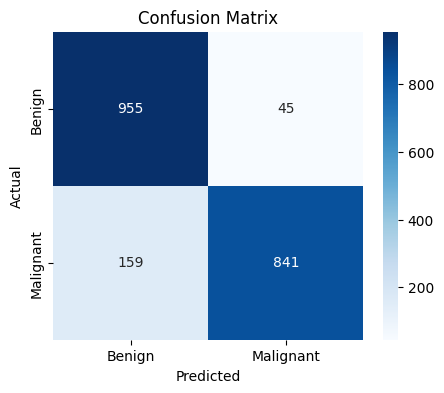

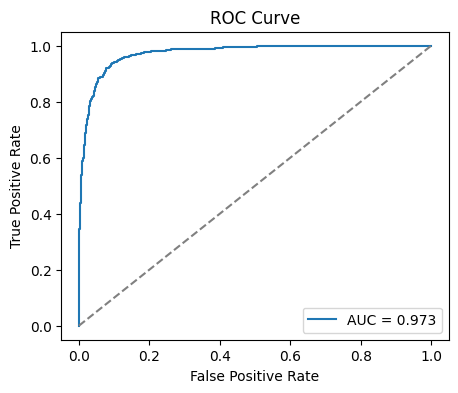

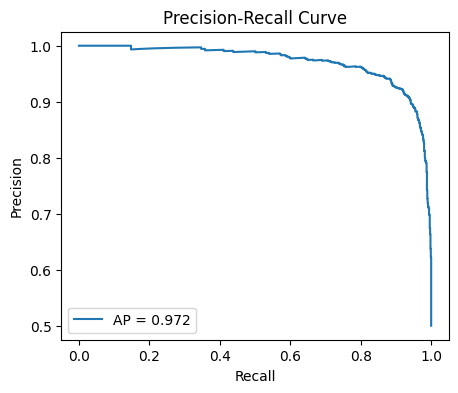

In [10]:
# Step 9: Evaluate Model on Test Data
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score

# Get predictions
y_true = test_generator.classes
y_prob = custom_cnn.predict(test_generator)
y_pred = (y_prob > 0.5).astype("int32").ravel()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


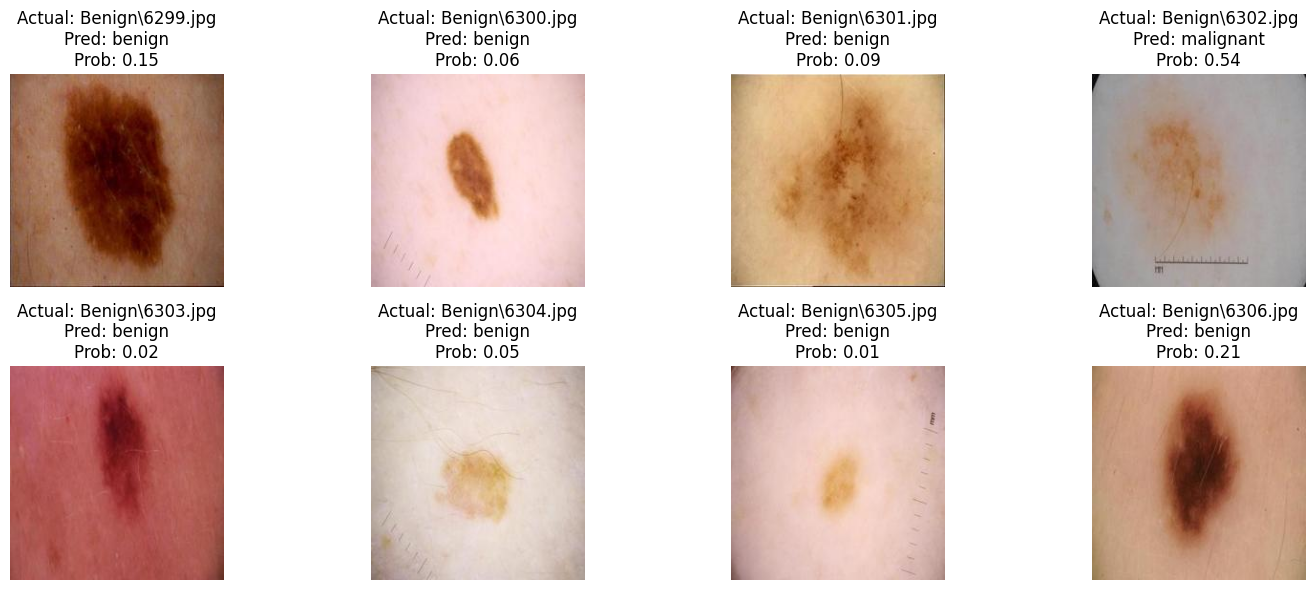

In [11]:
# Step 10: Visualize Predictions on Test Images
import matplotlib.image as mpimg

def show_predictions(generator, probs, n=8):
    plt.figure(figsize=(15, 6))
    for i in range(n):
        plt.subplot(2, 4, i+1)
        img_path = os.path.join(TEST_DIR, generator.filenames[i])
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis("off")
        
        actual = generator.filenames[i].split('/')[0]
        pred_prob = probs[i][0]
        pred_label = "malignant" if pred_prob >= 0.5 else "benign"
        
        plt.title(f"Actual: {actual}\nPred: {pred_label}\nProb: {pred_prob:.2f}")
    plt.tight_layout()
    plt.show()

# Call function
show_predictions(test_generator, y_prob, n=8)


Step 11: Transfer Learning with VGG16

In [12]:
# Step 11: Transfer Learning with VGG16
from tensorflow.keras.applications import VGG16

def build_vgg16_model(input_shape=(128,128,3)):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False
    
    # Add custom layers
    x = layers.Flatten()(base_model.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

vgg_model = build_vgg16_model(input_shape=(128,128,3))
vgg_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Step 12: Train VGG16 Model

In [13]:
# Step 12: Train VGG16
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)

history_vgg = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,  # usually converges faster
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 802s 3s/step - accuracy: 0.8287 - loss: 0.3931 - val_accuracy: 0.7552 - val_loss: 0.5075 - learning_rate: 0.0010
Epoch 2/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 798s 3s/step - accuracy: 0.8582 - loss: 0.3314 - val_accuracy: 0.7670 - val_loss: 0.4940 - learning_rate: 0.0010
Epoch 3/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 802s 3s/step - accuracy: 0.8597 - loss: 0.3216 - val_accuracy: 0.7574 - val_loss: 0.5168 - learning_rate: 0.0010
Epoch 4/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 794s 3s/step - accuracy: 0.8640 - loss: 0.3155 - val_accuracy: 0.7973 - val_loss: 0.4730 - learning_rate: 0.0010
Epoch 5/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 794s 3s/step - accuracy: 0.8654 - loss: 0.3112 - val_accuracy: 0.7423 - val_loss: 0.5090 - learning_rate: 0.0010
Epoch 6/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 793s 3s/step - accuracy: 0.8680 - loss: 0.3002 - val_accuracy: 0.7793 - val_loss: 0.5045 - learning_rate: 0.0010
Epoch 7/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8596 - loss: 0.31

In [14]:
# Save VGG16 model after training & prediction

# Save in HDF5 format
vgg_model.save("vgg16_skin_cancer.h5")
print("✅ VGG16 model saved as vgg16_skin_cancer.h5")

✅ VGG16 model saved as vgg16_skin_cancer.h5


Step 13: Evaluate VGG16

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 319s 159ms/step
Classification Report (VGG16):
              precision    recall  f1-score   support

      Benign       0.75      0.97      0.85      1000
   Malignant       0.96      0.68      0.80      1000

    accuracy                           0.83      2000
   macro avg       0.86      0.83      0.82      2000
weighted avg       0.86      0.83      0.82      2000



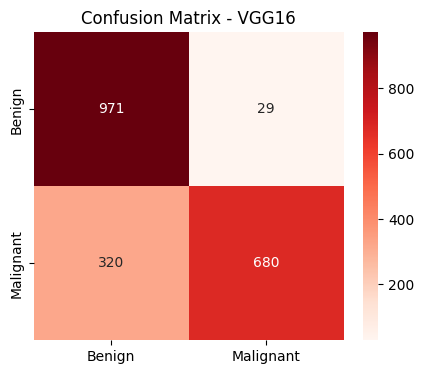

In [15]:
# Step 13: Evaluate VGG16 on test set
y_prob_vgg = vgg_model.predict(test_generator)
y_pred_vgg = (y_prob_vgg > 0.5).astype("int32").ravel()

print("Classification Report (VGG16):")
print(classification_report(y_true, y_pred_vgg, target_names=list(test_generator.class_indices.keys())))

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
plt.figure(figsize=(5,4))
sns.heatmap(cm_vgg, annot=True, fmt="d", cmap="Reds",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix - VGG16")
plt.show()


Step 14: Compare Model Performances

        Model  Accuracy   ROC AUC  Avg Precision
0  Custom CNN    0.8980  0.972978       0.971501
1       VGG16    0.8255  0.959735       0.957569


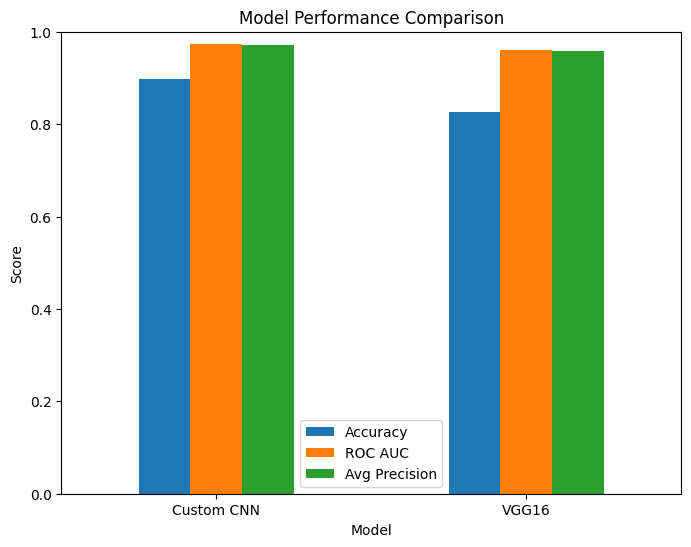

In [16]:
# Step 14: Model Performance Comparison

# --- Metrics for Custom CNN ---
from sklearn.metrics import roc_auc_score, average_precision_score

acc_custom = np.mean(y_true == y_pred)
roc_custom = roc_auc_score(y_true, y_prob)
ap_custom  = average_precision_score(y_true, y_prob)

# --- Metrics for VGG16 ---
acc_vgg = np.mean(y_true == y_pred_vgg)
roc_vgg = roc_auc_score(y_true, y_prob_vgg)
ap_vgg  = average_precision_score(y_true, y_prob_vgg)

# Create comparison DataFrame
results = pd.DataFrame({
    "Model": ["Custom CNN", "VGG16"],
    "Accuracy": [acc_custom, acc_vgg],
    "ROC AUC": [roc_custom, roc_vgg],
    "Avg Precision": [ap_custom, ap_vgg]
})

print(results)

# Plot comparison
results.set_index("Model").plot(kind="bar", figsize=(8,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()


Module 1: Dataset Acquisition & Exploration -->Visualization: Class Distribution (Bar Chart)

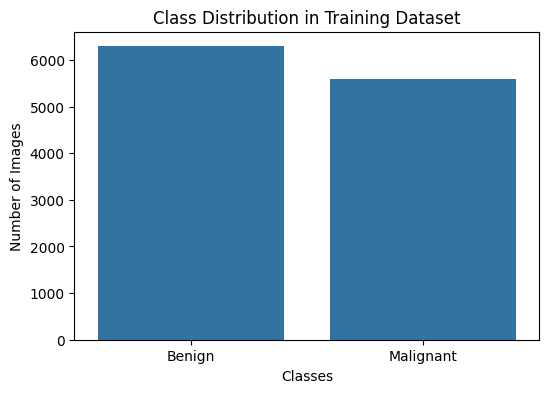

In [17]:
# Module 1: Class Distribution
import seaborn as sns

train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes}

plt.figure(figsize=(6,4))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title("Class Distribution in Training Dataset")
plt.ylabel("Number of Images")
plt.xlabel("Classes")
plt.show()


Module 2: Image Preprocessing & Augmentation -->Visualization: Pixel Intensity Histogram (Before & After Normalization)

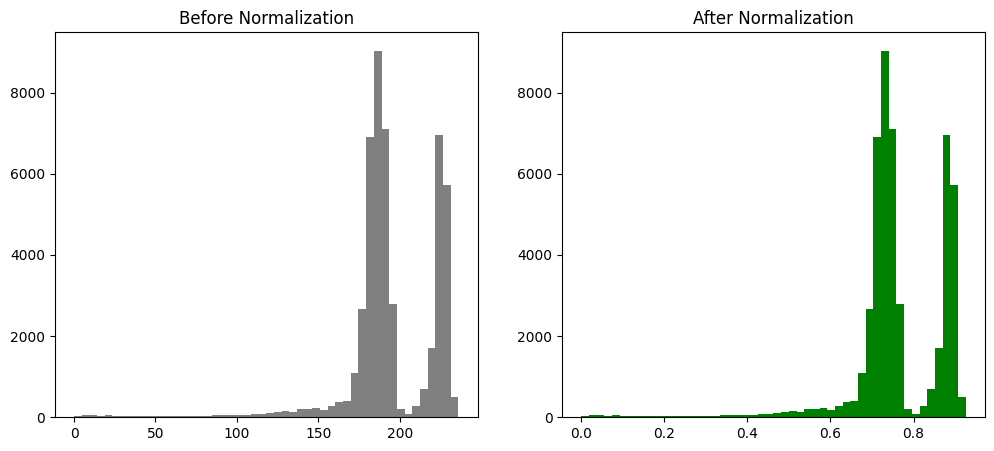

In [18]:
# Module 2: Pixel Intensity Distribution
import cv2

# Pick one random image
sample_img_path = os.path.join(TRAIN_DIR, classes[0], os.listdir(os.path.join(TRAIN_DIR, classes[0]))[0])
img_raw = cv2.imread(sample_img_path)
img_resized = cv2.resize(img_raw, (128,128))

# Normalize
img_norm = img_resized / 255.0

# Plot histogram
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(img_resized.ravel(), bins=50, color='gray')
plt.title("Before Normalization")

plt.subplot(1,2,2)
plt.hist(img_norm.ravel(), bins=50, color='green')
plt.title("After Normalization")

plt.show()


Module 3: Feature Extraction & Model Selection -->Visualization: KPI (Best Model Accuracy vs Parameters)

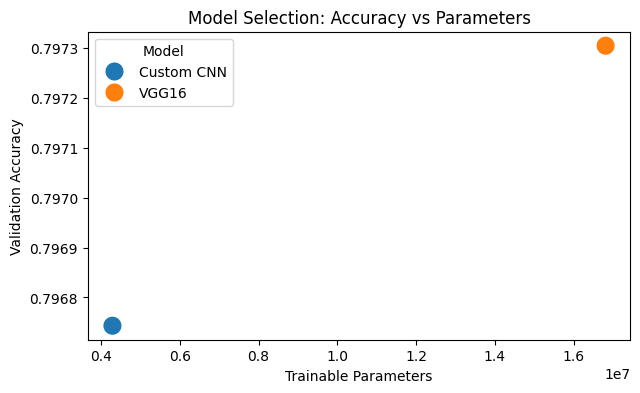

        Model  Validation Accuracy  Trainable Params
0  Custom CNN               0.7967           4289217
1       VGG16               0.7973          16812353


In [22]:
# Module 3: Model Comparison KPI
results = pd.DataFrame({
    "Model": ["Custom CNN", "VGG16"],
    "Validation Accuracy": [max(history.history['val_accuracy']),
                            max(history_vgg.history['val_accuracy'])],
    "Trainable Params": [custom_cnn.count_params(), vgg_model.count_params()]
})

plt.figure(figsize=(7,4))
sns.scatterplot(x="Trainable Params", y="Validation Accuracy", data=results, hue="Model", s=200)
plt.title("Model Selection: Accuracy vs Parameters")
plt.xlabel("Trainable Parameters")
plt.ylabel("Validation Accuracy")
plt.show()

print(results)


Module 4: Model Training & Validation -->Visualization: Training vs Validation Loss (Line Chart)

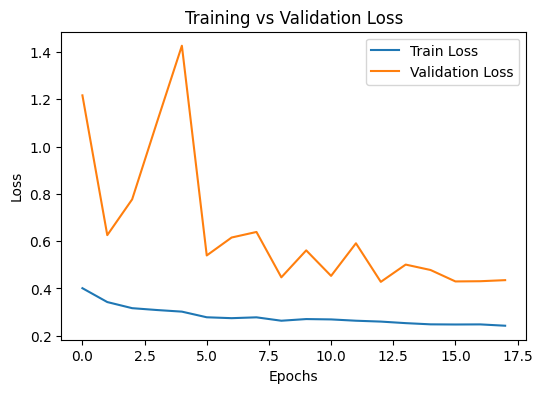

In [20]:
# Module 4: Training vs Validation Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


Module 5: Testing & Results Interpretation -->
Visualization: Correct vs Incorrect Predictions (Pie Chart)

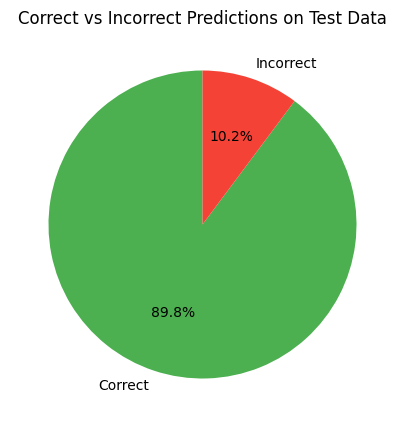

In [21]:
# Module 5: Correct vs Incorrect Predictions
correct = sum(y_true == y_pred)
incorrect = sum(y_true != y_pred)

plt.figure(figsize=(5,5))
plt.pie([correct, incorrect],
        labels=["Correct", "Incorrect"],
        autopct='%1.1f%%',
        colors=["#4CAF50","#F44336"],
        startangle=90)
plt.title("Correct vs Incorrect Predictions on Test Data")
plt.show()


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load both saved models
cnn_model = load_model("custom_cnn_model.h5")        # Custom CNN
vgg_model = load_model("vgg16_skin_cancer.h5")      # VGG16 Transfer Learning


def predict_skin_cancer(image_path, model, model_name="Custom CNN"):
    """
    Predict skin cancer from an input image using the given model.
    
    Parameters:
    - image_path: str, path to the image file
    - model: Keras model (loaded with load_model)
    - model_name: str, name of the model (for display only)
    """
    # Choose target size based on model
    if model_name == "VGG16":
        target_size = (128, 128)
    else:
        target_size = (128, 128)  # Custom CNN
    
    # Load and preprocess image
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    prediction = model.predict(img_array)[0][0]  # get scalar output
    class_label = "Malignant" if prediction > 0.5 else "Benign"
    
    # Show result
    plt.imshow(img)
    plt.title(f"{model_name} Prediction: {class_label} ({prediction:.2f})")
    plt.axis("off")
    plt.show()
    
    return class_label, prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


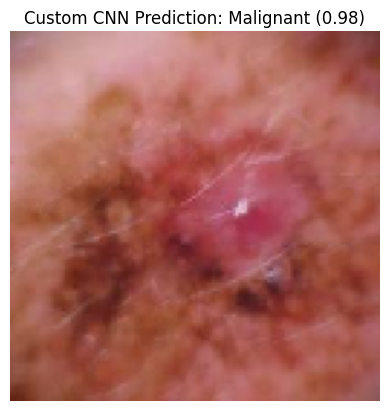

('Malignant', np.float32(0.97645473))

In [37]:
# Test with Custom CNN
predict_skin_cancer(r"C:\Users\SIDDU\Desktop\Melanoma_Cancer_Image_Dataset\test\Malignant\5602.jpg", cnn_model, model_name="Custom CNN")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step


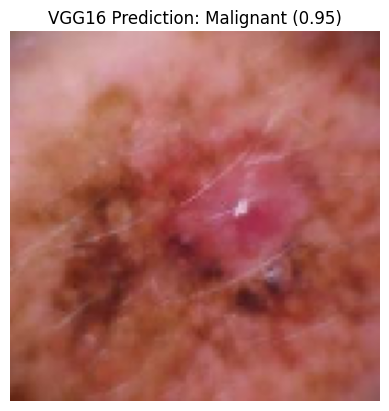

('Malignant', np.float32(0.9524052))

In [38]:
# Test with VGG16
predict_skin_cancer(r"C:\Users\SIDDU\Desktop\Melanoma_Cancer_Image_Dataset\test\Malignant\5602.jpg", vgg_model, model_name="VGG16")